In [1]:
from river import stream 
from river import datasets
from river import tree, ensemble, forest
from river import metrics
from river import compose, preprocessing, linear_model
from river import feature_extraction
from river import drift
from itertools import islice
from river import base
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
metric = metrics.MSE() 
import itertools
from tqdm import tqdm
import pandas as pd
import warnings
from datetime import datetime
import numpy as np
from collections import defaultdict,deque
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import geopandas as gpd
from shapely.geometry import Point

In [2]:
# !pip install geopandas
# !pip install shapely.geometry


In [3]:
from class_transformer import FeatureDistrict
from centroid_drift import CentroidDriftDetector


In [4]:
# %pip install ipywidgets

In [5]:
# %pip install kagglehub

In [6]:
# Na calym datasecie
# Manhattan        921379
# Queens            58774
# Brooklyn          18071
# Bronx               877
# NaN                 855
# Staten Island        44

In [7]:
# %pip install geopandas shapely pyproj pyogrio --no-cache-dir

In [8]:
#%pip install geopy

In [9]:
# !pip install geopandas

In [10]:
with open("config_dataset.json", "r", encoding="utf-8-sig") as f:
    config = json.load(f)

In [11]:
df_warsaw=pd.read_csv("warsaw_synthetic.csv")


In [12]:
df_warsaw.head(5)

,timestamp,start_lat,start_lon,end_lat,end_lon,distance_km,travel_time_min,hour,day_of_week,is_weekend,rush_hour,is_holiday,pickup_d,dropoff_d,weather_clear,weather_fog,weather_rain,weather_snow
0,2025-01-01 00:09:06,52.253264,20.981510,52.159729,21.126328,17.786888,25.131083,0,2,0,0,1,Left,Left,1,0,0,0
1,2025-01-01 00:17:26,52.191368,21.043104,52.145980,21.037312,6.231378,11.619191,0,2,0,0,1,Left,Left,0,0,1,0
2,2025-01-01 00:34:09,52.267529,21.032690,52.149947,21.053613,17.694589,55.764620,0,2,0,0,1,Right,Left,0,0,0,1
3,2025-01-01 00:35:16,52.177431,21.062454,52.218237,20.999811,7.952929,19.220696,0,2,0,0,1,Left,Left,0,1,0,0
4,2025-01-01 00:42:18,52.253970,21.220869,52.196762,20.895023,28.631239,42.313451,0,2,0,0,1,Right,Left,0,0,1,0


In [13]:
def warsaw_stream(df):
    for row in df:
        x = dict(row)
        y = x.get('travel_time_min')
        x.pop('travel_time_min',None)
        yield x, y


In [14]:
df_airplanes=pd.read_csv("Airplanes_modified.csv")

In [15]:
def airline_stream(df):
    for row in df:
        x = dict(row)
        y = x.get('ArrDelay')
        x.pop('ArrDelay',None)
        yield x, y

In [16]:
df_taxi=pd.read_csv("taxi_dataset_ordered.csv")

In [17]:
df_taxi.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id0190469,2,2016-01-01 00:00:17,2016-01-01 00:14:26,5,-73.981743,40.719158,-73.938828,40.829182,N,849
1,id1665586,1,2016-01-01 00:00:53,2016-01-01 00:22:27,1,-73.985085,40.747166,-73.958038,40.717491,N,1294
2,id1210365,2,2016-01-01 00:01:01,2016-01-01 00:07:49,5,-73.965279,40.801041,-73.947479,40.815170,N,408
3,id3888279,1,2016-01-01 00:01:14,2016-01-01 00:05:54,1,-73.982292,40.751331,-73.991341,40.750340,N,280
4,id0924227,1,2016-01-01 00:01:20,2016-01-01 00:13:36,1,-73.970108,40.759800,-73.989357,40.742989,N,736


In [18]:
def taxi_stream(df):
    for row in df:
        x = dict(row)
        y = x.get('trip_duration')
        y=round(float(y/60),2)
        x.pop('trip_duration',None)
        yield x, y

In [19]:
# Wybór datasetu

In [20]:
DATASET = "Warsaw"
cfg = config[DATASET]

In [21]:
if DATASET=="Airplanes":
    rows = df_airplanes.to_dict(orient='records')
    data = airline_stream(rows)
elif DATASET=="Warsaw":
    rows = df_warsaw.to_dict(orient='records')
    data = warsaw_stream(rows)
elif DATASET=="Taxi":
    rows = df_taxi.to_dict(orient='records')
    data = taxi_stream(rows)
else:
    raise Exception("Dataset ERROR")



In [22]:

full_stream=data
x, y = next(data)
print(x)
print(y)

{'timestamp': '2025-01-01 00:09:06', 'start_lat': 52.2532644, 'start_lon': 20.9815095, 'end_lat': 52.159729, 'end_lon': 21.1263282, 'distance_km': 17.78688849267649, 'hour': 0, 'day_of_week': 2, 'is_weekend': 0, 'rush_hour': 0, 'is_holiday': 1, 'pickup_d': 'Left', 'dropoff_d': 'Left', 'weather_clear': 1, 'weather_fog': 0, 'weather_rain': 0, 'weather_snow': 0}
25.13108336695775


In [23]:
districts = cfg["district_list"]

error_window_config = cfg["error_window_config"]
adwin_configs = cfg["adwin_configs"]

columns_to_drop = cfg["columns_to_drop"]

WARMUP_DAYS = cfg["WARMUP_DAYS"]
PH_THRESHOLD = cfg["PH_THRESHOLD"]
PH_MIN_INSTANCES = cfg["PH_MIN_INSTANCES"]
PH_ALPHA = cfg["PH_ALPHA"]

In [24]:
# Wybor sampli

In [25]:
s=100000 #5 min dla 300000 sample

stream = itertools.islice(full_stream, s)

In [26]:
# Flow

In [27]:

models = {
    d: ensemble.SRPRegressor(n_models=10, seed=0)
    for d in districts}

drift_detectors = {
    d: drift.ADWIN(delta=adwin_configs[d]["delta"])
    for d in districts
}



In [28]:
local_counts  = {d: 0 for d in districts}
local_counts_drift  = {d: 0 for d in districts}

daily_errors  = defaultdict(lambda: defaultdict(list))
count_samples=0
drift_timestamps  = {d: [] for d in districts}
drift_instances   = {d: [] for d in districts}
error_windows    = defaultdict(list)             
window_rmse_series = defaultdict(lambda: defaultdict(list))

In [29]:
transformer = FeatureDistrict(
    dataset=DATASET,
    columns_to_drop=columns_to_drop,
)
 
feature_drift_detectors = {d: CentroidDriftDetector(
    warmup_days=WARMUP_DAYS,
    ph_threshold=PH_THRESHOLD,
    ph_min_instances=PH_MIN_INSTANCES,
    ph_alpha=PH_ALPHA,
) for d in districts}
 

In [30]:
start_time = time.time()
for x, y in stream:
    x = transformer.transform_one(x)
    timestamp = pd.to_datetime(x["timestamp"])
    date = timestamp.date()
    x.pop("timestamp", None)
 
    if x["within_district"] == 1:
        district = x["pickup_district"]
    else:
        district = "Global"
    x.pop("pickup_district", None)
    x.pop("dropoff_district", None)
 
    model = models[district]
    y_pred = model.predict_one(x)
 
    count_samples += 1
    if count_samples % 10000 == 0:
        elapsed = time.time() - start_time
        progress = count_samples / s
        print(
            f"({progress*100:.1f}%) | "
            f"Elapsed: {elapsed/60:.2f} min"
        )
 
    ERROR_WINDOW = error_window_config[district]
    local_counts[district] += 1
    local_counts_drift[district] += 1
    instance_count = local_counts[district]
 
    #Concept drift
    feature_vec = np.array(list(x.values()), dtype=float)
    feature_drift_detectors[district].update(feature_vec, timestamp, instance_count)
 
    if feature_drift_detectors[district].drift_detected:
        last = feature_drift_detectors[district].drift_log[-1]
        print(f"[Feature DRIFT] {district} | day: {last['date']} "
              f"| dist: {last['distance']:.4f} | instance: {instance_count}")

    
    if y_pred is not None:
        # if y_pred < 0:
        #     y_pred = 0
 
        mae = abs(y_pred - y)
        daily_errors[district][date].append(mae)

        #Error drift
        sq_err = (y_pred - y) ** 2
        error_windows[district].append(sq_err)
        if len(error_windows[district]) > ERROR_WINDOW:
            error_windows[district].pop(0)
 
        if len(error_windows[district]) == ERROR_WINDOW:
            rmse = np.sqrt(sum(error_windows[district]) / ERROR_WINDOW)
            window_rmse_series[district][timestamp].append(rmse)
 
            drift_detectors[district].update(rmse)
 
            if local_counts_drift[district] > 10000 and drift_detectors[district].drift_detected:
                local_counts_drift[district] = 0
                print(f"[Error DRIFT] {district} | instance: {instance_count} "
                      f"| RMSE: {rmse:.4f}")
                drift_instances[district].append(instance_count)
                drift_timestamps[district].append(timestamp)
 
    model.learn_one(x, y)

(10.0%) | Elapsed: 0.27 min
(20.0%) | Elapsed: 0.57 min
[Error DRIFT] Global | instance: 10031 | RMSE: 14.6022
(30.0%) | Elapsed: 0.88 min
[Feature DRIFT] Right | day: 2025-02-12 00:00:00 | dist: 0.3274 | instance: 5794
[Error DRIFT] Left | instance: 10077 | RMSE: 13.5358
(40.0%) | Elapsed: 1.20 min
[Error DRIFT] Global | instance: 20079 | RMSE: 17.2791
[Feature DRIFT] Right | day: 2025-03-05 00:00:00 | dist: 2.0656 | instance: 8842
(50.0%) | Elapsed: 1.54 min
[Error DRIFT] Right | instance: 10155 | RMSE: 13.4841
[Feature DRIFT] Left | day: 2025-03-16 00:00:00 | dist: 1.7003 | instance: 17386
(60.0%) | Elapsed: 1.84 min
[Feature DRIFT] Right | day: 2025-03-23 00:00:00 | dist: 2.5159 | instance: 11527
[Error DRIFT] Global | instance: 30191 | RMSE: 15.5260
[Error DRIFT] Left | instance: 20093 | RMSE: 9.7842
[Feature DRIFT] Global | day: 2025-03-28 00:00:00 | dist: 0.3518 | instance: 31322
(70.0%) | Elapsed: 2.16 min
[Feature DRIFT] Right | day: 2025-04-15 00:00:00 | dist: 0.4006 | instan

In [31]:
# feature_drift_detectors["Right"].drift_log

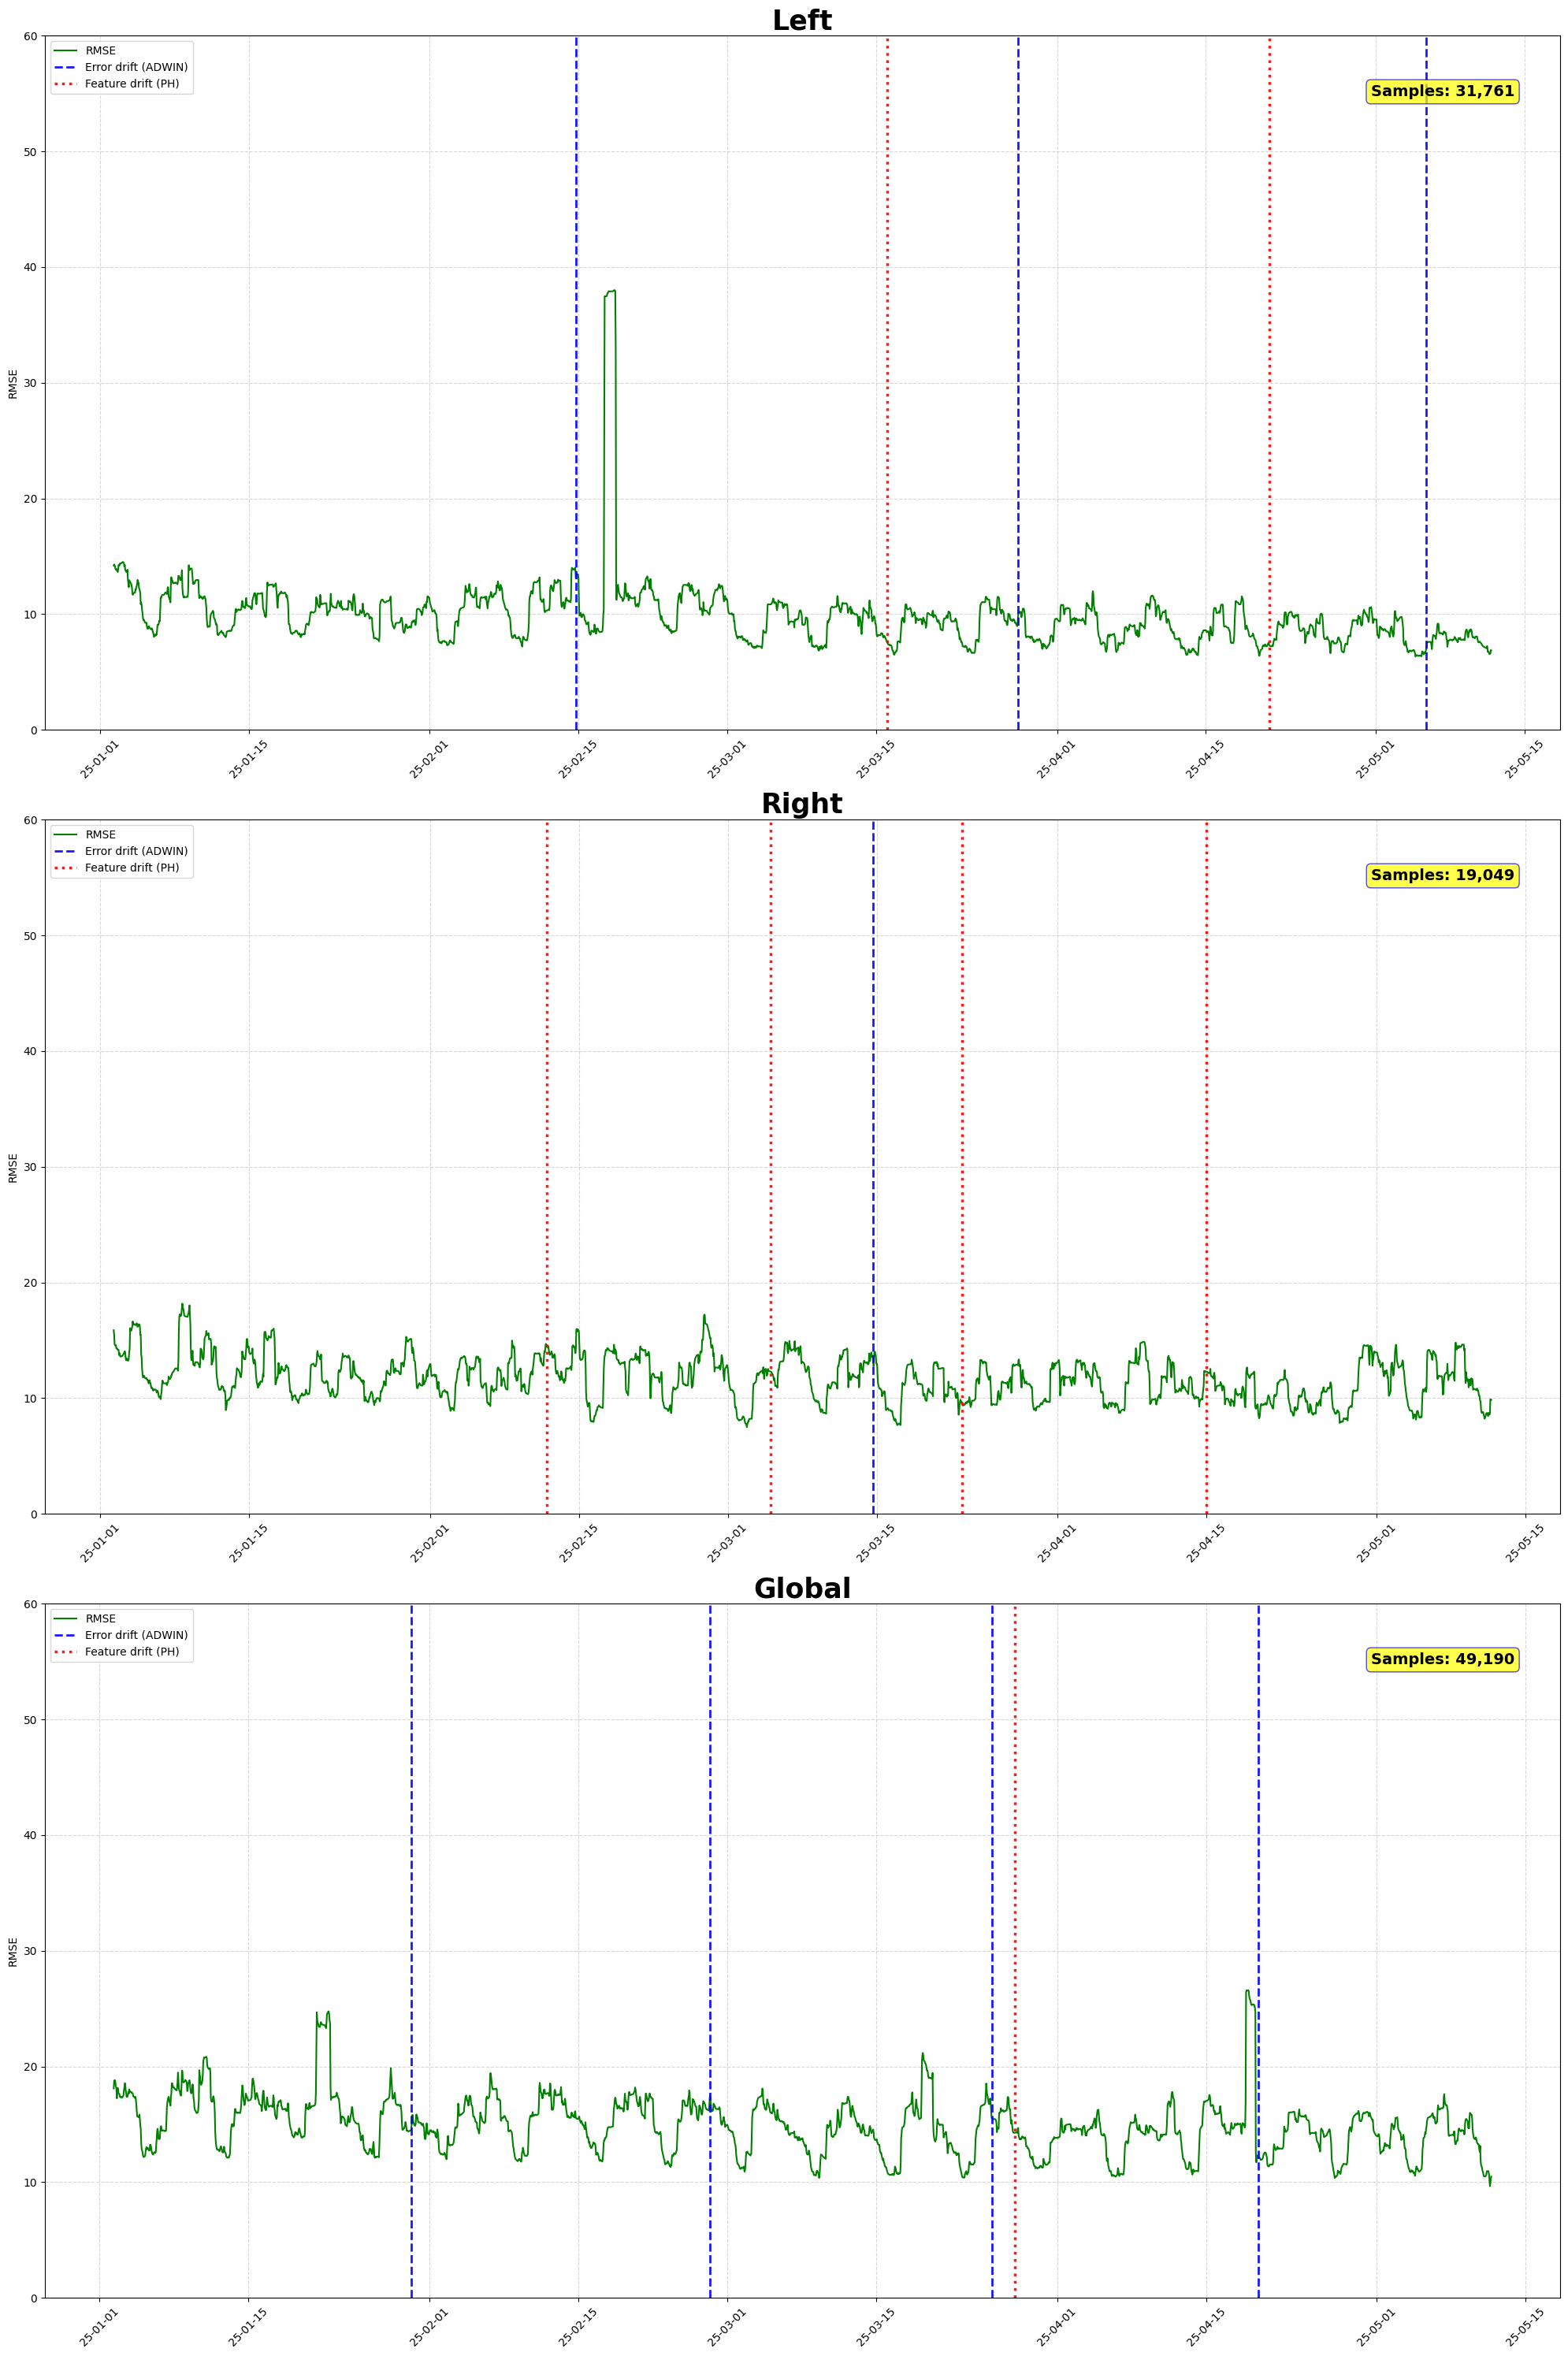

In [32]:
if DATASET=="Airplanes":
    k=5
elif DATASET=="Taxi":
    k=4
elif DATASET=="Warsaw":
    k=3
district_list = districts

fig, axes = plt.subplots(k, 1, figsize=(20, 30), sharex=False)

for ax, dist in zip(axes, district_list):

    dist_data = window_rmse_series.get(dist, {})

    timestamps = sorted(dist_data.keys())
    mean_rmses = [np.mean(dist_data[ts]) for ts in timestamps]

    ax.plot(timestamps, mean_rmses, color='green', label='RMSE')
    count = local_counts.get(dist, 0)
    
    ax.text(
        0.97, 0.93,
        f"Samples: {count:,}",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7, edgecolor='blue'),
        fontsize=14,
        fontweight='bold'
    )

    if dist in drift_timestamps:
        for i, time in enumerate(drift_timestamps[dist]):
            ax.axvline(
                pd.to_datetime(time),
                color="blue",
                linestyle='--',
                linewidth=2,
                alpha=0.9,
                label="Error drift (ADWIN)" if i == 0 else ""
            )

    fd = feature_drift_detectors.get(dist)
    if fd.drift_log:
        for i, drift in enumerate(fd.drift_log):
            ax.axvline(
                pd.to_datetime(drift["date"]),
                color="red",
                linestyle=':',
                linewidth=2.5,
                alpha=0.9,
                label="Feature drift (PH)" if i == 0 else ""
            )

    ax.set_ylim(0, 30)
    ax.set_title(dist, fontsize=25, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper left', frameon=True, facecolor='white')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"plot_final_{DATASET}.png", dpi=300, bbox_inches='tight')
plt.show()